In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

In [5]:
data=pd.read_csv('RFM_dataset.csv')
df=pd.DataFrame(data)
df.head()

,Customer Id,Order Id,Sales,order date (DateOrders)
0,20755,77202,327.75,1/31/2018 22:56
1,19492,75939,327.75,1/13/2018 12:27
2,19491,75938,327.75,1/13/2018 12:06
3,19490,75937,327.75,1/13/2018 11:45
4,19489,75936,327.75,1/13/2018 11:24


Creating Recency, Frequency and Monetary(RFM)

In [6]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
snapshot_date = (df['order date (DateOrders)'].max()+ pd.Timedelta(days=1))
rfm = (df.groupby('Customer Id').agg({'order date (DateOrders)': lambda x:(snapshot_date - x.max()).days,'Order Id': 'nunique','Sales': 'sum'}).reset_index())

In [7]:
# rfm.head()
rfm.columns = ['Customer Id','Recency','Frequency','Monetary']

Convert to RFM Scores (1–5)

In [8]:
# We don't compare raw values (Instead we rank customers).
rfm['R_Score'] = pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])

rfm['RFM_Total'] = (
    rfm['R_Score'].astype(int)
    + rfm['F_Score'].astype(int)
    + rfm['M_Score'].astype(int)
)

In [9]:
rfm[['R_Score','F_Score','M_Score']].describe()

rfm.head()

,Customer Id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total
0,1,793,1,499.950012,1,1,2,4
1,2,137,4,1819.730034,3,3,3,9
2,3,230,5,3537.680094,2,4,5,11
3,4,381,4,1719.630030,1,3,3,7
4,5,458,3,1274.750023,1,3,3,7


Customer Segments

In [10]:
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost Customers'
rfm['Customer Segment'] = rfm['RFM_Total'].apply(segment_customer)

In [11]:
rfm['Customer Segment'].value_counts()

Customer Segment
Potential Loyalists    11768
Loyal Customers         5803
At Risk                 1511
Champions               1493
Lost Customers            77
Name: count, dtype: int64

Customer Segment Distribution ⭐

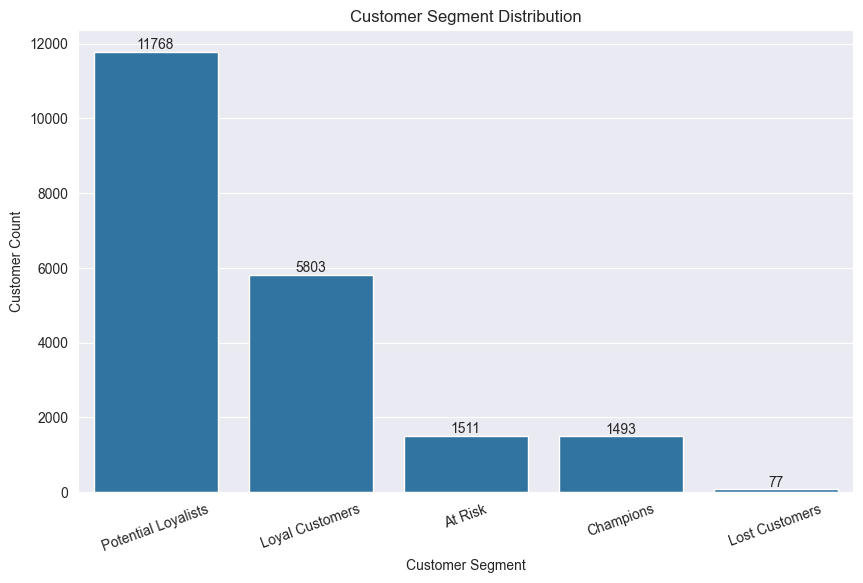

In [12]:
segment_count = (rfm['Customer Segment'].value_counts().reset_index())

segment_count.columns = ['Customer Segment','Customer Count']
plt.figure(figsize=(10,6))

ax = sns.barplot(data=segment_count,x='Customer Segment',y='Customer Count')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Customer Segment Distribution')
plt.xticks(rotation=20)
plt.show()

KPI Cards

In [13]:
total_customers = rfm['Customer Id'].nunique()
avg_recency = rfm['Recency'].mean()
avg_frequency = rfm['Frequency'].mean()
avg_monetary = rfm['Monetary'].mean()

print(f"Total Customers: {total_customers:,}")
print(f"Average Recency: {avg_recency:.0f}")
print(f"Average Frequency: {avg_frequency:.2f}")
print(f"Average Monetary Value: {avg_monetary:.2f}")

Total Customers: 20,652
Average Recency: 221
Average Frequency: 3.18
Average Monetary Value: 1781.17


Recency Distribution

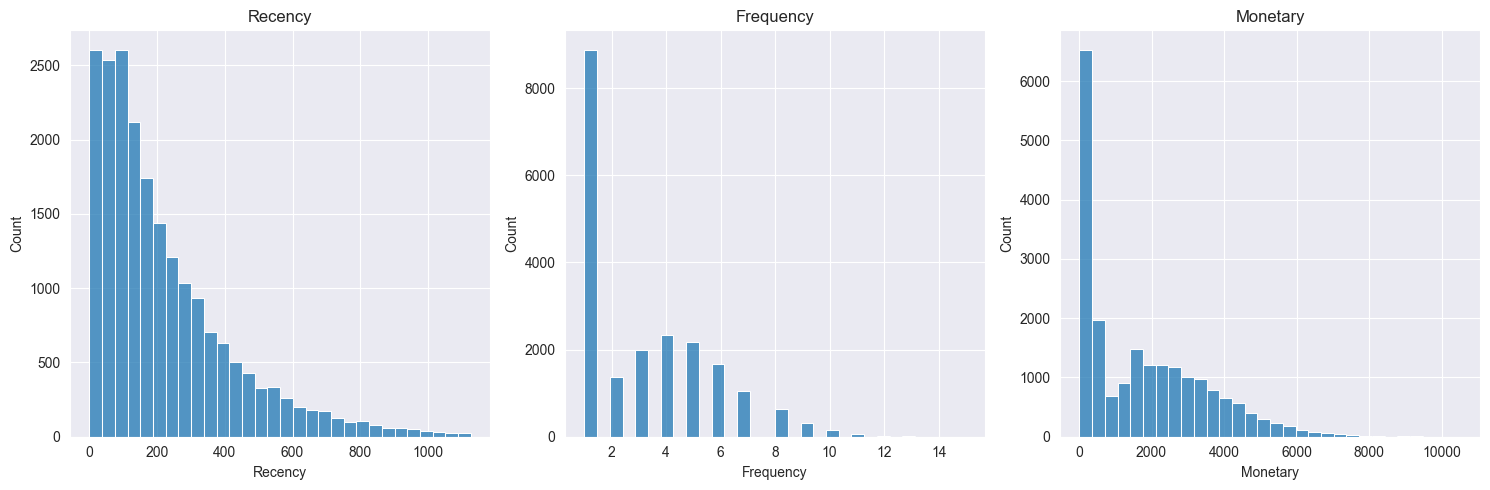

In [14]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], bins=30)
plt.title('Recency')

plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], bins=30)
plt.title('Frequency')

plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], bins=30)
plt.title('Monetary')

plt.tight_layout()
plt.show()

Revenue Contribution by Segment ⭐

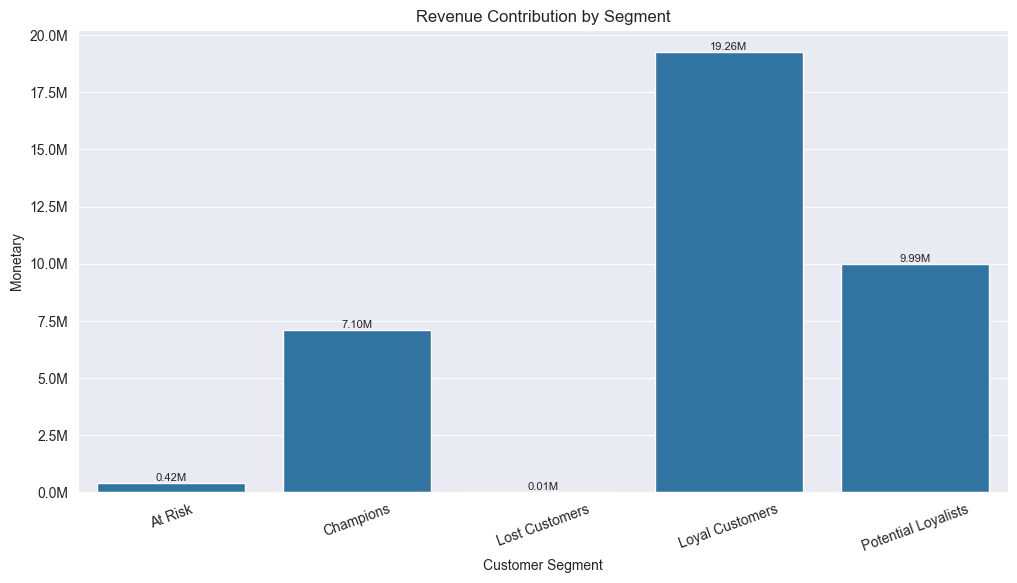

In [15]:
import matplotlib.ticker as ticker
rev_contribution=rfm.groupby('Customer Segment')['Monetary'].sum()
plt.figure(figsize=(12,6))

ax = sns.barplot(rev_contribution)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1000000:.2f}M' for v in container.datavalues],
        fontsize=8)

plt.title('Revenue Contribution by Segment')
plt.xticks(rotation=20)
plt.show()

Recency vs Monetary

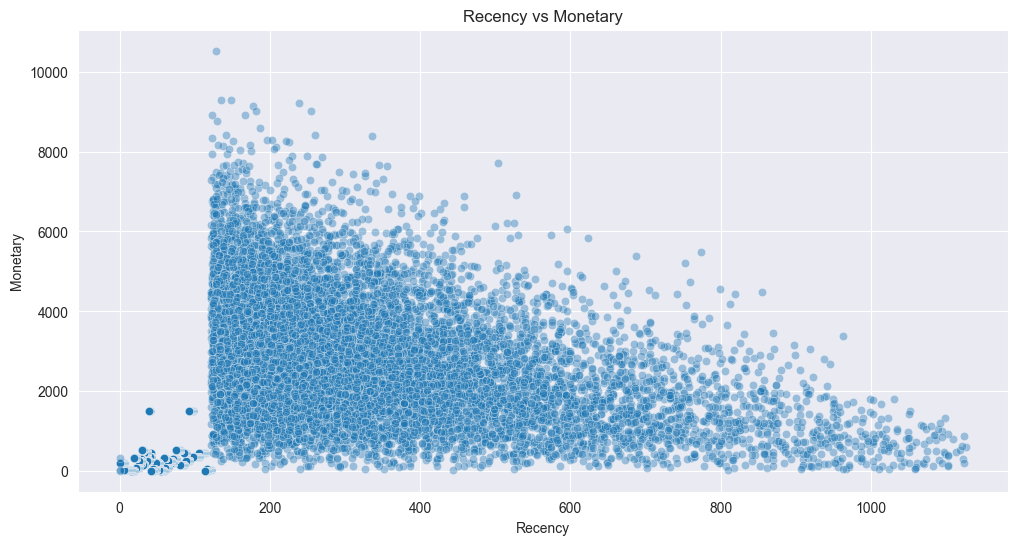

In [16]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=rfm,x='Recency',y='Monetary',alpha=0.4)
plt.title('Recency vs Monetary')
plt.show()

Frequency vs Monetary ⭐

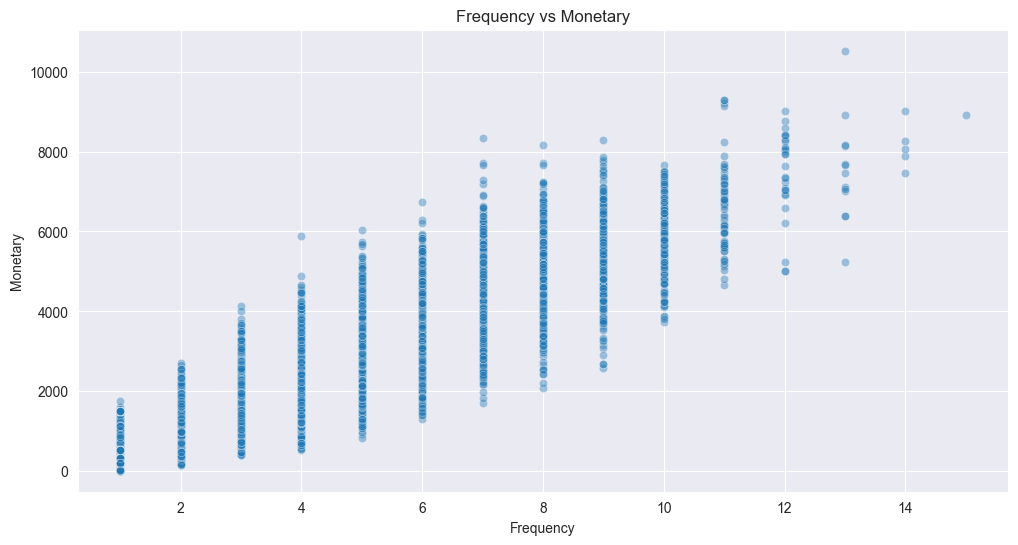

In [21]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=rfm,x='Frequency',y='Monetary',alpha=0.4)
plt.title('Frequency vs Monetary')
plt.show()

Top 10 Customers by Revenue

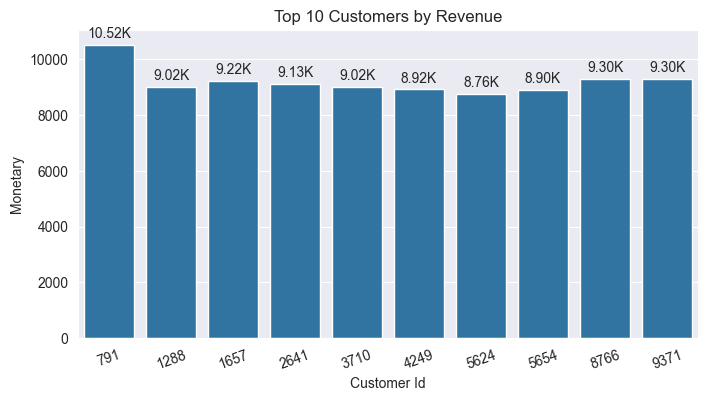

In [18]:
import matplotlib.ticker as ticker
rev_contribution=rfm.groupby('Customer Id')['Monetary'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
ax = sns.barplot(rev_contribution)
for container in ax.containers:
    ax.bar_label(container,labels=[f'{v/1000:.2f}K' for v in container.datavalues],padding=3)
plt.title('Top 10 Customers by Revenue')
plt.xticks(rotation=20)
plt.show()

Top 10 Customers by Frequency

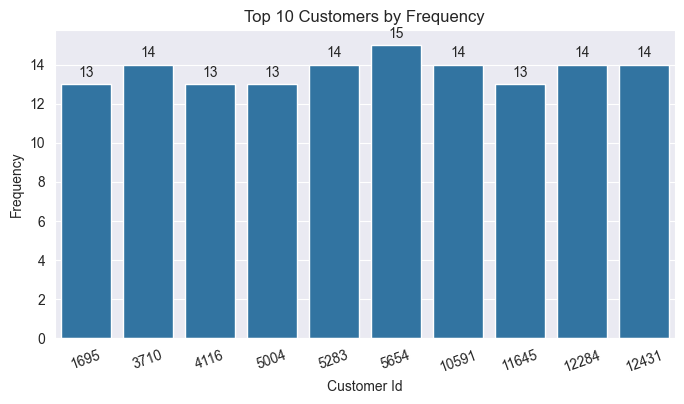

In [19]:
import matplotlib.ticker as ticker
rev_contribution=rfm.groupby('Customer Id')['Frequency'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
ax = sns.barplot(rev_contribution)
for container in ax.containers:
    ax.bar_label(container,fmt='%d',padding=3)
plt.title('Top 10 Customers by Frequency')
plt.xticks(rotation=20)
plt.show()

RFM Heatmap ⭐

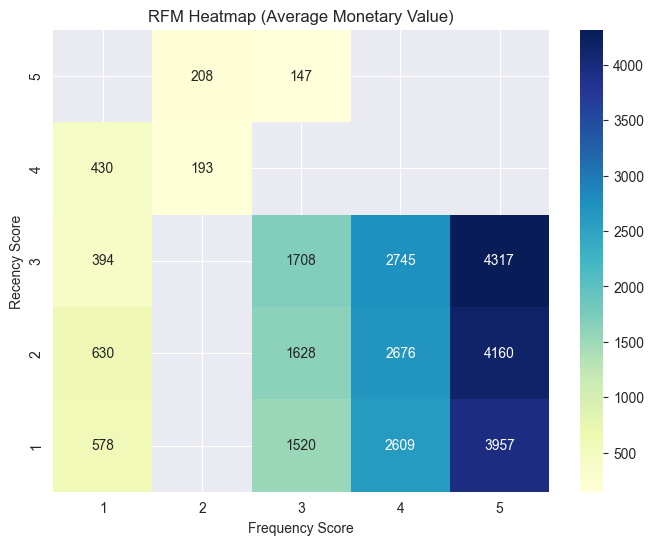

In [20]:
heatmap_data = rfm.pivot_table(values='Monetary',index='R_Score',columns='F_Score',aggfunc='mean')
plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data,annot=True,fmt='.0f',cmap='YlGnBu')
plt.title('RFM Heatmap (Average Monetary Value)')
plt.xlabel('Frequency Score')
plt.ylabel('Recency Score')
plt.show()